My goal is to make some 3D plots of q-C surfaces as well as contour plots. This is also a way to understand what a binary system looks like

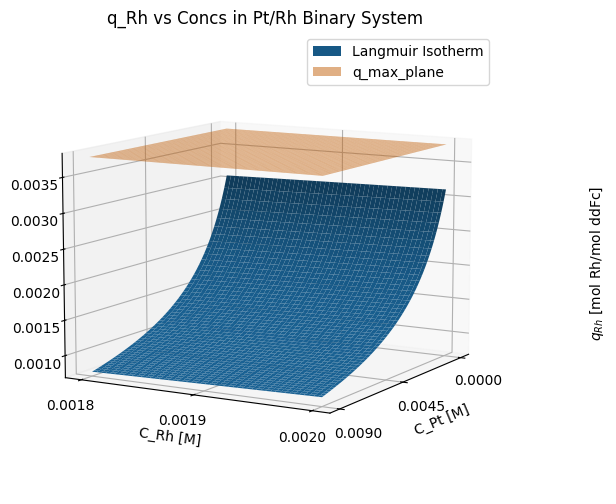

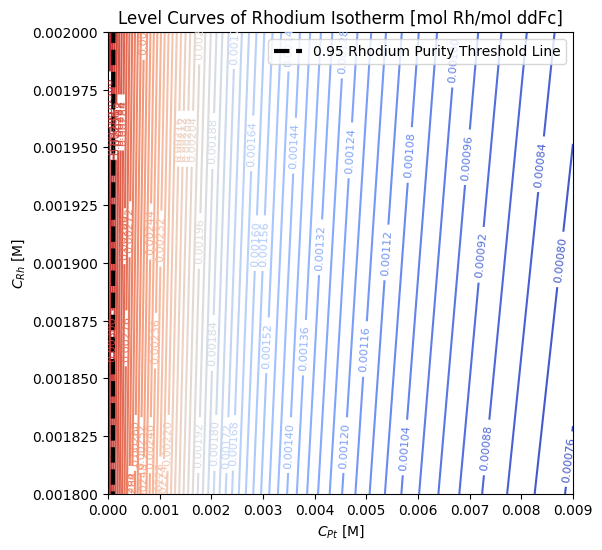

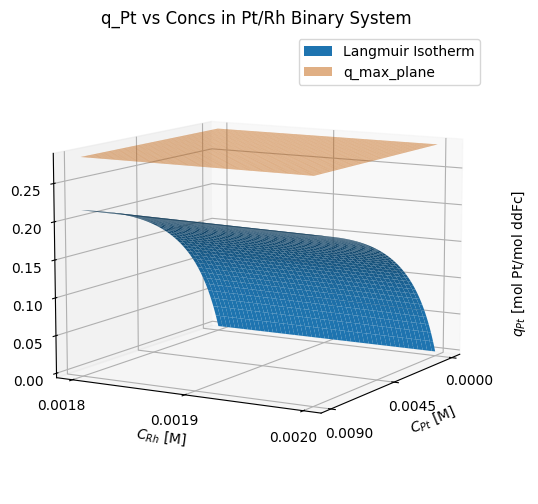

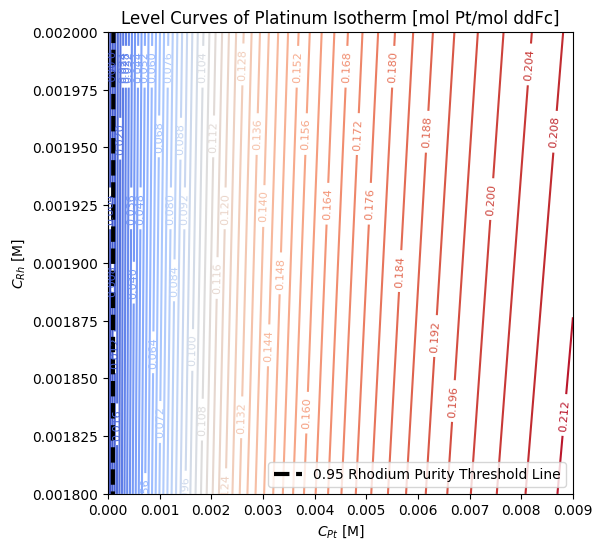

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D

def denom_fcn(K_eq_arr: np.ndarray, C_arr: np.ndarray):
  return 1+np.dot(K_eq_arr,C_arr)
def q_func_langmuir_relation(q_max_arr: np.ndarray, K_eq_arr: np.ndarray, C_arr: np.ndarray):
  denom=denom_fcn(K_eq_arr,C_arr)
  q_arr=q_max_arr*K_eq_arr*C_arr/denom
  return q_arr

purity_threshold = 0.95
recovery_threshold=0.9
C_in_tot=0.02
C_in=C_in_tot*np.array([0.45,0.45,0.1])
C_Pt_in=C_in[0]
C_Rh_in=C_in[2]

q_max_arr = np.array([0.283186498156831,0.569456410590181,0.00376984198947194]) #mol PGM/mol ddFc
K_Eq_arr = np.array([1822.14319447879,2662.60543887326, 2401.64491456341])

q_max_arr_Pt_Rh = np.array([q_max_arr[0],q_max_arr[2]])
K_Eq_arr_Pt_Rh = np.array([K_Eq_arr[0],K_Eq_arr[2]])

C_Pt = np.linspace(0, C_Pt_in, 200)
C_Rh = np.linspace(C_Rh_in*recovery_threshold, C_Rh_in, 200)
X, Y = np.meshgrid(C_Pt, C_Rh)

def total_q_langmuir(q_max_arr_vals, K_eq_arr_vals, c_pt_val, c_rh_val):
    C_arr_single_point = np.array([c_pt_val, c_rh_val])
    q_vals_for_point = q_func_langmuir_relation(q_max_arr_vals, K_eq_arr_vals, C_arr_single_point)
    return q_vals_for_point[-1] # Returns Rh component

def total_q_langmuir_Pt(q_max_arr_vals, K_eq_arr_vals, c_pt_val, c_rh_val):
    C_arr_single_point = np.array([c_pt_val, c_rh_val])
    q_vals_for_point = q_func_langmuir_relation(q_max_arr_vals, K_eq_arr_vals, C_arr_single_point)
    return q_vals_for_point[0] # Returns Pt component

def q_max_dummy_fcn_Rh(q_max_arr_vals,x,y):
  return q_max_arr_vals[-1]

def q_max_dummy_fcn_Pt(q_max_arr_vals,x,y):
  return q_max_arr_vals[0]

total_q_langmuir_vectorized = np.vectorize(total_q_langmuir, signature='(n),(n),(),()->()')
total_q_langmuir_Pt_vectorized = np.vectorize(total_q_langmuir_Pt, signature='(n),(n),(),()->()') # New vectorized function for Pt

# The q_max_dummy_fcn_Rh does not actually use x and y, it just returns a constant.
# Using np.full_like is more appropriate for creating a constant plane.
# q_max_dummy_fcn_Rh_vectorized = np.vectorize(q_max_dummy_fcn_Rh, signature='(n),(),()->()')
Z = total_q_langmuir_vectorized(q_max_arr_Pt_Rh, K_Eq_arr_Pt_Rh, X, Y)
threshold_plane= np.full_like(X, q_max_arr_Pt_Rh[-1]) # Corrected line

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, label='Langmuir Isotherm')
ax.plot_surface(X, Y, threshold_plane, alpha=0.5, label='q_max_plane')
ax.set_xticks(np.linspace(0, C_Pt_in, 3))
ax.set_yticks(np.linspace(C_Rh_in*recovery_threshold, C_Rh_in, 3))
ax.set_xlabel('C_Pt [M]')
ax.set_ylabel('C_Rh [M]')
ax.set_title('q_Rh vs Concs in Pt/Rh Binary System') # Changed title for clarity
ax.legend()
ax.text2D(
    1.2, 0.5,
    r'$q_{Rh}$ [mol Rh/mol ddFc]',
    transform=ax.transAxes,
    rotation=90,
    va='center'
)
angles=np.linspace(0,360,10)
ax.view_init(10, 30)


x_line = np.linspace(0, C_Pt_in, 2000)
y_line = np.linspace(C_Rh_in*recovery_threshold, C_Rh_in, 2000)

fig, ax = plt.subplots(figsize=(6,6))

contours = ax.contour(X, Y, Z, levels=60,cmap='coolwarm')
ax.clabel(contours, inline=True, fontsize=8)
ax.plot(x_line,x_line*purity_threshold/(1-purity_threshold), linestyle='--', color='k',label=str(purity_threshold)+' Rhodium Purity Threshold Line', linewidth=3)

# ax.plot(x_line)
ax.set_xlabel(r"$C_{Pt}$ [M]")
ax.set_ylabel(r"$C_{Rh}$ [M]")
ax.set_title("Level Curves of Rhodium Isotherm [mol Rh/mol ddFc]")

# set limits ONCE
ax.set_xlim(0, C_Pt_in)
ax.set_ylim(C_Rh_in*recovery_threshold, C_Rh_in)
ax.legend()

# choose ONE of these two options:

# Option A: keep your limits exactly (recommended for your plot)
ax.set_aspect('auto')            # or just remove aspect setting entirely

# Option B: truly equal data units, but allow axes box to change shape
# ax.set_aspect('equal', adjustable='datalim')

plt.show()





# total_q_langmuir_vectorized = np.vectorize(total_q_langmuir)
# The q_max_dummy_fcn_Pt does not actually use x and y, it just returns a constant.
# Using np.full_like is more appropriate for creating a constant plane.
# q_max_dummy_fcn_Pt_vectorized = np.vectorize(q_max_dummy_fcn_Pt, signature='(n),(n),(),()->()') # Incorrect signature
Z = total_q_langmuir_Pt_vectorized(q_max_arr_Pt_Rh, K_Eq_arr_Pt_Rh, X, Y) # Use the new vectorized function for Pt
threshold_plane= np.full_like(X, q_max_arr_Pt_Rh[0]) # Corrected line

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, label='Langmuir Isotherm')
ax.plot_surface(X, Y, threshold_plane, alpha=0.5, label='q_max_plane')
ax.set_xticks(np.linspace(0, C_Pt_in, 3))
ax.set_yticks(np.linspace(C_Rh_in*recovery_threshold, C_Rh_in, 3))
ax.set_xlabel(r"$C_{Pt}$ [M]")
ax.set_ylabel(r"$C_{Rh}$ [M]")
ax.set_title('q_Pt vs Concs in Pt/Rh Binary System') # Changed title for clarity
ax.legend()
ax.text2D(
    1.05, 0.5,
    r'$q_{Pt}$ [mol Pt/mol ddFc]',
    transform=ax.transAxes,
    rotation=90,
    va='center'
)
angles=np.linspace(0,360,10)
ax.view_init(10, 30)

fig, ax = plt.subplots(figsize=(6,6))

contours = ax.contour(X, Y, Z, levels=60, cmap='coolwarm')
ax.clabel(contours, inline=True, fontsize=8)

ax.plot(x_line,x_line*purity_threshold/(1-purity_threshold), linestyle='--', color='k',label=str(purity_threshold)+' Rhodium Purity Threshold Line', linewidth=3)
r"$X_{axis}$"
ax.set_xlabel(r"$C_{Pt}$ [M]")
ax.set_ylabel(r"$C_{Rh}$ [M]")
ax.set_title("Level Curves of Platinum Isotherm [mol Pt/mol ddFc]")

# set limits ONCE
ax.set_xlim(0, C_Pt_in)
ax.set_ylim(C_Rh_in*recovery_threshold, C_Rh_in)
ax.legend()

# choose ONE of these two options:

# Option A: keep your limits exactly (recommended for your plot)
ax.set_aspect('auto')            # or just remove aspect setting entirely

# Option B: truly equal data units, but allow axes box to change shape
# ax.set_aspect('equal', adjustable='datalim')

plt.show()

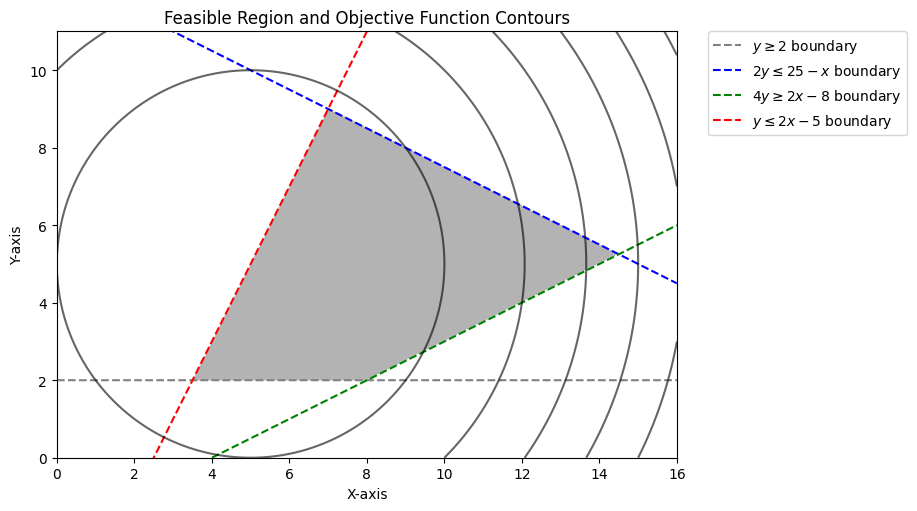

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the search space
d = np.linspace(0, 16, 400) # Range for x and y
x, y = np.meshgrid(d, d)

# Define constraints as boolean conditions:
# y >= 2
# 2y <= 25 - x  =>  y <= (25 - x) / 2
# 4y >= 2x - 8  =>  y >= (2x - 8) / 4
# y <= 2x - 5

# Create a boolean mask for the feasible region
feasible_region = (y >= 2) & \
                  (2 * y <= 25 - x) & \
                  (4 * y >= 2 * x - 8) & \
                  (y <= 2 * x - 5)

# 2. Plot the feasible region using imshow
plt.figure(figsize=(8, 6))
# Use .astype(int) to convert boolean to 0/1 for imshow
plt.imshow(feasible_region.astype(int), extent=(x.min(), x.max(), y.min(), y.max()),
           origin="lower", cmap="Greys", alpha=0.3)

# 3. Optional: Plot the boundary lines of the constraints
# These lines help visualize the exact boundaries of the inequalities
x_line = np.linspace(0, 16, 2000)
plt.plot(x_line, 2 * np.ones_like(x_line), label=r'$y \geq 2$ boundary', color='gray', linestyle='--')
plt.plot(x_line, (25 - x_line) / 2.0, label=r'$2y \leq 25-x$ boundary', color='blue', linestyle='--')
plt.plot(x_line, (2 * x_line - 8) / 4.0, label=r'$4y \geq 2x - 8$ boundary', color='green', linestyle='--')
plt.plot(x_line, 2 * x_line - 5, label=r'$y \leq 2x-5$ boundary', color='red', linestyle='--')


# Optional: Plot the objective function contours over the feasible region
# Example objective function: Z = (x-5)^2 + (y-5)^2 (minimizing this would aim for the center)
Z = (x - 5)**2 + (y - 5)**2
plt.contour(x, y, Z, levels=10, colors='black', alpha=0.6) # Add contour lines

# Set plot limits and add labels
plt.xlim(0, 16)
plt.ylim(0, 11)
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.title("Feasible Region and Objective Function Contours")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.) # Position legend outside the plot area

plt.show()
